In [4]:
import pandas as pd

# Load and preprocess the MPRA data
df_mpra = pd.read_csv(
    '/media/zihengc/T7/mpra3_lib_analysis/indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv',
    index_col=0
)
df_mpra = df_mpra.drop_duplicates(subset='enhancer_id', keep='first')

# Function to pad sequences to 500bp
def pad_sequence(seq):
    if len(seq) < 500:
        total_padding = 500 - len(seq)
        left_padding = 'N' * (total_padding // 2)
        right_padding = 'N' * (total_padding - len(left_padding))
        return f"{left_padding}{seq}{right_padding}"
    else:
        return seq

# Function to save the DataFrame as a FASTA file
def save_as_fasta(df, file_name):
    with open(file_name, 'w') as f:
        for _, row in df.iterrows():
            f.write(f">{row['enhancer_id']}\n{row['padded_seq']}\n")

# Function to process data based on FDR condition
def process_data(fdr_condition, file_suffix):
    df_differential = pd.read_csv(
        '/media/zihengc/T7/mpra3_lib_analysis/enhancer_activities_differential/20240626_comparative_THP1_LPSIFNGvsNaive_DifferentialEnhancer.csv',
        index_col=0
    )
    df_filtered = df_differential[fdr_condition(df_differential['fdr'])]
    df_mpra_filtered = df_mpra[df_mpra['enhancer_id'].isin(df_filtered.index)].copy()
    df_mpra_filtered['padded_seq'] = df_mpra_filtered['enhancer_seq'].apply(pad_sequence)
    
    # Save as FASTA
    fasta_file = f'sequence_for_prediction/{file_suffix}.fasta'
    save_as_fasta(df_mpra_filtered, fasta_file)
    
    # Reset index and save as CSV
    csv_file = f'sequence_for_prediction/{file_suffix}.csv'
    df_mpra_filtered.reset_index().to_csv(csv_file)

# Define conditions and file suffixes
conditions = [
    (lambda fdr: fdr <= 0.05, '20241002_MPRA_500bp_SNPandControl_Ns_227bpenhancers_THP1LPSIFNG_differentialMPRAenhancers'),
    (lambda fdr: fdr >= 0.2, '20241002_MPRA_500bp_SNPandControl_Ns_227bpenhancers_THP1LPSIFNG_differentialMPRAenhancers_fdr02background')
]

# Process data for each condition
for fdr_condition, file_suffix in conditions:
    process_data(fdr_condition, file_suffix)


In [2]:

import pandas as pd

# Load and preprocess the MPRA data
df_mpra = pd.read_csv(
    '../../mpra3_lib_analysis/indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv',
    index_col=0
)

df_differential = pd.read_csv(
    '../../mpra3_lib_analysis/enhancer_activities_differential/20240626_comparative_THP1_LPSIFNGvsNaive_DifferentialEnhancer.csv',
    index_col=0
)



In [4]:
df_differential

,statistic,pval,fdr,df.test,df.dna,df.rna.full,df.rna.red,logFC
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,0.069416,0.792189,0.897476,1,28,3,2,0.013954
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,3.554249,0.059393,0.218401,1,28,3,2,-0.076673
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,2.334430,0.126541,0.346284,1,28,3,2,0.075781
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,1.442222,0.229780,0.480400,1,28,3,2,-0.055137
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,3.338005,0.067697,0.235358,1,28,3,2,0.156054
...,...,...,...,...,...,...,...,...
ref:rs9281938:PEAKCENTER:chr6:32576282:T:TA:32576044:32576544:32576294,0.064768,0.799113,0.900275,1,28,3,2,-0.013004
ref:rs9304646:PEAKCENTER:chr19:44947151:T:A:44946977:44947477:44947227,0.288979,0.590876,0.785798,1,28,3,2,0.021256
ref:rs9357546:PEAKCENTER:chr6:47549495:C:T:47549371:47549664:47549511,2.936344,0.086607,0.283022,1,28,3,2,-0.105724
ref:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583,0.036658,0.848164,0.928910,1,28,3,2,-0.009751


In [6]:
import os
os.listdir("prediction")

['10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences',
 '10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences_negative',
 '5kbmodels_20240618_MPRA_500bp_SNPandControl_500bpbarcodes_20240826',
 '5kbmodels_20240809_MPRA_500bp_SNPandControl_Ns_227bpbarcodes_20240826',
 '10kbmodels_20240618_MPRA_500bp_SNPandControl_500bpbarcodes_20240825',
 '10kbmodels_20240809_MPRA_500bp_SNPandControl_Ns_227bpbarcodes_20240825']

In [39]:
ml_prediction_barcode = pd.read_csv("prediction/10kbmodels_20240618_MPRA_500bp_SNPandControl_500bpbarcodes_20240825/THP1_LPSIFNG-Calvin_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv",header=None)
import numpy as np
ml_prediction_barcode = ml_prediction_barcode.groupby(np.arange(len(ml_prediction_barcode))//2).mean()
ml_prediction_barcode.index = df_mpra.index
ml_prediction_barcode['enhancer_id']=df_mpra['enhancer_id']
ml_prediction_enhancer = ml_prediction_barcode.groupby('enhancer_id').mean()
ml_prediction_enhancer = ml_prediction_enhancer.rename(columns = {0:"ml_lps"})
lps = pd.merge(df_differential,ml_prediction_enhancer,left_index=True,right_index=True)

In [40]:
ml_prediction_barcode = pd.read_csv("prediction/10kbmodels_20240618_MPRA_500bp_SNPandControl_500bpbarcodes_20240825/THP1_Naive-Calvin_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv",header=None)
import numpy as np
ml_prediction_barcode = ml_prediction_barcode.groupby(np.arange(len(ml_prediction_barcode))//2).mean()
ml_prediction_barcode.index = df_mpra.index
ml_prediction_barcode['enhancer_id']=df_mpra['enhancer_id']
ml_prediction_enhancer = ml_prediction_barcode.groupby('enhancer_id').mean()
ml_prediction_enhancer = ml_prediction_enhancer.rename(columns = {0:"ml_naive"})
naive = pd.merge(lps,ml_prediction_enhancer,left_index=True,right_index=True)

In [42]:
naive.to_csv("differential_enhancer_mpra_model.csv")

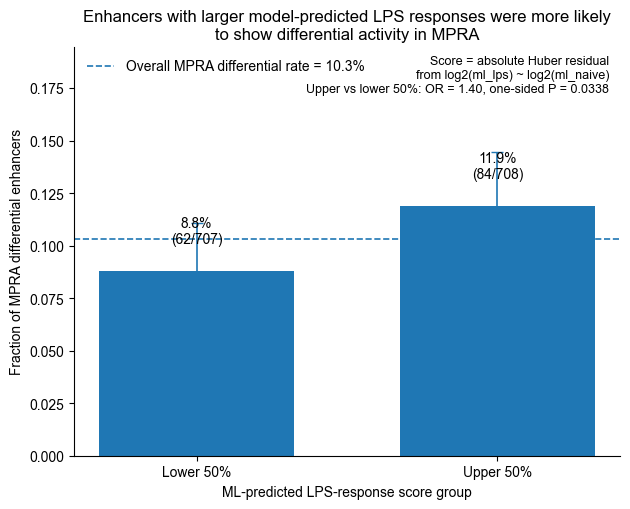

  score_group    n  mpra_hits  median_score  hit_fraction    ci_low   ci_high
0   Lower 50%  707         62      0.204932      0.087694  0.069010  0.110835
1   Upper 50%  708         84      0.692422      0.118644  0.096858  0.144547

Upper vs lower 50% OR = 1.4004, one-sided P = 0.03376


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor
from scipy.stats import fisher_exact

# =========================
# Input: existing dataframe
# =========================
# df must contain:
#   ml_naive, ml_lps, fdr
#
# Example:
# df = your_dataframe.copy()

df = naive.copy()

# =========================
# Basic settings
# =========================
eps = 1e-9  # avoid log(0)

# Illustrator-friendly vector text
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Liberation Sans", "DejaVu Sans"]
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# =========================
# Define MPRA differential hits
# =========================
# Here: differential enhancer = FDR < 0.05
df["mpra_diff"] = df["fdr"] < 0.05

# =========================
# Build ML-predicted LPS-response score
# =========================
# Use robust regression in log space:
#   log2(ml_lps) ~ log2(ml_naive)
# Score = absolute residual from the fitted line

df["log_ml_naive"] = np.log2(df["ml_naive"] + eps)
df["log_ml_lps"] = np.log2(df["ml_lps"] + eps)

huber = HuberRegressor()
huber.fit(df[["log_ml_naive"]], df["log_ml_lps"])

df["pred_log_ml_lps"] = huber.predict(df[["log_ml_naive"]])
df["ml_lps_response_score"] = np.abs(df["log_ml_lps"] - df["pred_log_ml_lps"])

# =========================
# Split enhancers into upper 50% vs lower 50%
# =========================
median_score = df["ml_lps_response_score"].median()
df["score_group"] = np.where(
    df["ml_lps_response_score"] >= median_score,
    "Upper 50%",
    "Lower 50%"
)

# =========================
# Summarize MPRA hit fraction in each group
# =========================
summary = (
    df.groupby("score_group", observed=True)
      .agg(
          n=("mpra_diff", "size"),
          mpra_hits=("mpra_diff", "sum"),
          median_score=("ml_lps_response_score", "median"),
      )
      .reindex(["Lower 50%", "Upper 50%"])
      .reset_index()
)

summary["hit_fraction"] = summary["mpra_hits"] / summary["n"]

# Wilson confidence interval for proportions
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    half = z * np.sqrt((phat * (1 - phat) + z**2 / (4 * n)) / n) / denom
    return center - half, center + half

cis = summary.apply(lambda r: wilson_ci(int(r["mpra_hits"]), int(r["n"])), axis=1)
summary["ci_low"] = [x[0] for x in cis]
summary["ci_high"] = [x[1] for x in cis]

# =========================
# Fisher's exact test
# =========================
# one-sided test: is Upper 50% enriched for MPRA differential enhancers?
a = int(summary.loc[summary["score_group"] == "Upper 50%", "mpra_hits"].iloc[0])
b = int(summary.loc[summary["score_group"] == "Upper 50%", "n"].iloc[0] - a)
c = int(summary.loc[summary["score_group"] == "Lower 50%", "mpra_hits"].iloc[0])
d = int(summary.loc[summary["score_group"] == "Lower 50%", "n"].iloc[0] - c)

odds_ratio, p_value = fisher_exact([[a, b], [c, d]], alternative="greater")

background_rate = df["mpra_diff"].mean()

# =========================
# Make the figure
# =========================
fig, ax = plt.subplots(figsize=(6.4, 5.2))

x = np.arange(len(summary))
heights = summary["hit_fraction"].to_numpy()
yerr = np.vstack([
    heights - summary["ci_low"].to_numpy(),
    summary["ci_high"].to_numpy() - heights
])

ax.bar(x, heights, width=0.65)
ax.errorbar(x, heights, yerr=yerr, fmt="none", capsize=4, linewidth=1.2)

ax.axhline(
    background_rate,
    linestyle="--",
    linewidth=1.2,
    label=f"Overall MPRA differential rate = {background_rate:.1%}"
)

ax.set_xticks(x)
ax.set_xticklabels(summary["score_group"])
ax.set_ylabel("Fraction of MPRA differential enhancers")
ax.set_xlabel("ML-predicted LPS-response score group")
ax.set_title(
    "Enhancers with larger model-predicted LPS responses were more likely\n"
    "to show differential activity in MPRA"
)

# annotate bars
for xi, row in zip(x, summary.itertuples(index=False)):
    ax.text(
        xi,
        row.hit_fraction + 0.012,
        f"{row.hit_fraction:.1%}\n({int(row.mpra_hits)}/{int(row.n)})",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# stats text
ax.text(
    0.98,
    0.98,
    "Score = absolute Huber residual\n"
    "from log2(ml_lps) ~ log2(ml_naive)\n"
    f"Upper vs lower 50%: OR = {odds_ratio:.2f}, one-sided P = {p_value:.3g}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
)

ax.set_ylim(0, max(summary["ci_high"].max() + 0.05, background_rate + 0.08))
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()

# =========================
# Save outputs
# =========================
fig.savefig("grant_ml_predicts_mpra_differential_enhancers.pdf", bbox_inches="tight")
fig.savefig("grant_ml_predicts_mpra_differential_enhancers.png", dpi=300, bbox_inches="tight")

# Optional: save summary table
summary.to_csv("grant_ml_predicts_mpra_differential_enhancers_summary.csv", index=False)

plt.show()

# =========================
# Print key results
# =========================
print(summary)
print(f"\nUpper vs lower 50% OR = {odds_ratio:.4f}, one-sided P = {p_value:.4g}")